In [ ]:
# Import libraries

import numpy as np
import pandas as pd
import scipy.stats as stats
from statsmodels.stats.proportion import proportions_ztest
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded.")

Libraries loaded.


In [ ]:
from google.colab import files
import io

# Re-load the dataset with the correct semicolon separator
df = pd.read_csv('/content/student-mat.csv', sep=';')

print(f"Dataset shape: {df.shape}")
display(df.head())

Dataset shape: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [ ]:
# Inspect data types, missing values, and general info
print("=== Dataset Info ===")
df.info()

print("\n=== Missing Values Summary ===")
print(df.isnull().sum())

print("\n=== Numerical Summary Statistics ===")
display(df.describe())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    o

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


Number of duplicate rows: 0


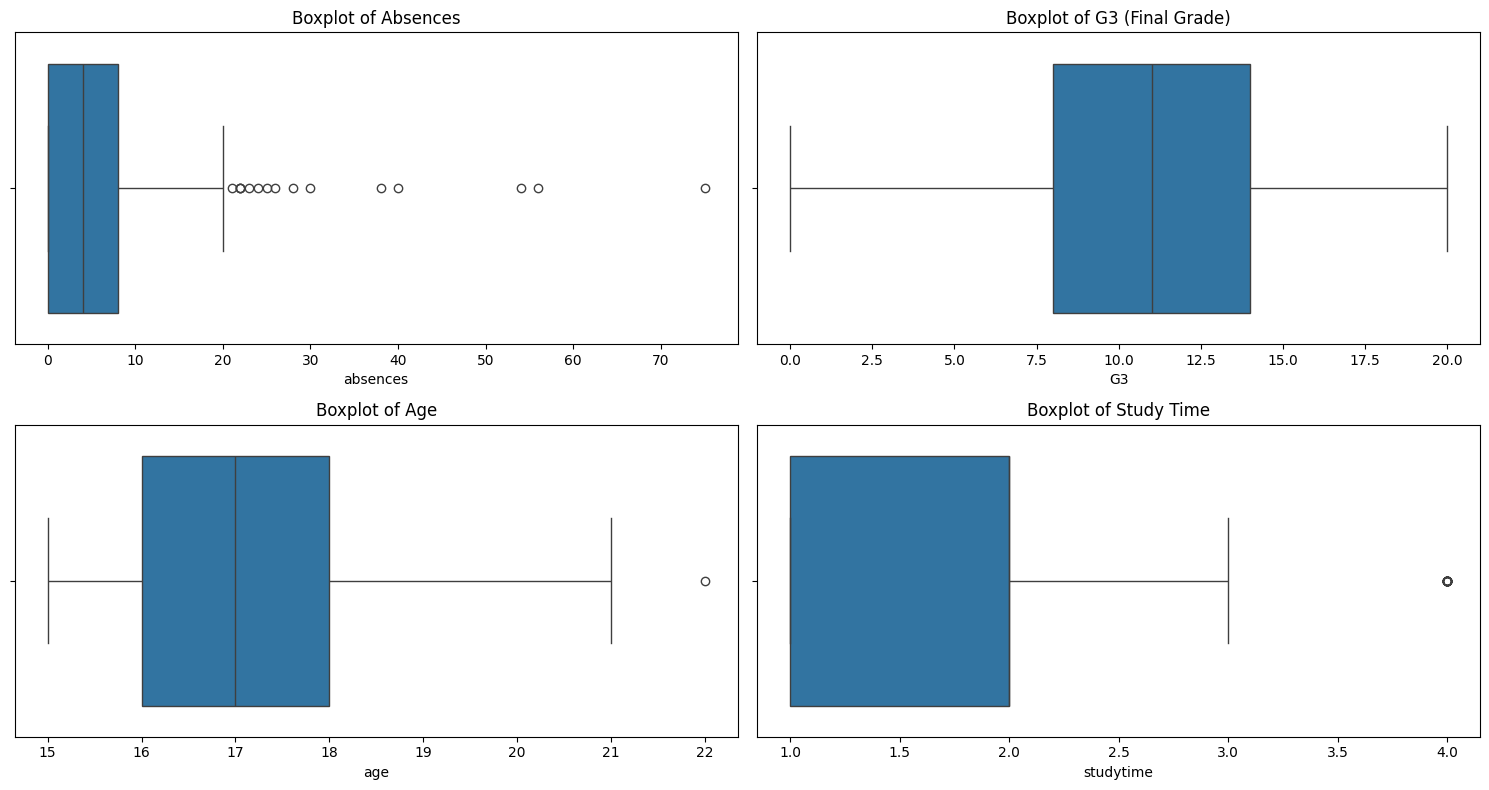

In [ ]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# Visualize outliers in numerical columns using boxplots
plt.figure(figsize=(15, 8))
plt.subplot(2, 2, 1)
sns.boxplot(x=df['absences'])
plt.title('Boxplot of Absences')

plt.subplot(2, 2, 2)
sns.boxplot(x=df['G3'])
plt.title('Boxplot of G3 (Final Grade)')

plt.subplot(2, 2, 3)
sns.boxplot(x=df['age'])
plt.title('Boxplot of Age')

plt.subplot(2, 2, 4)
sns.boxplot(x=df['studytime'])
plt.title('Boxplot of Study Time')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Create a working copy of the dataframe
df_preprocessed = df.copy()

# 1. Handling outliers for 'absences'
q_95 = df_preprocessed['absences'].quantile(0.95)
df_preprocessed['absences'] = np.where(df_preprocessed['absences'] > q_95, q_95, df_preprocessed['absences'])

# 2. Feature Engineering (Only past grades are aggregated to avoid data leakage with G3)
df_preprocessed['past_grades'] = df_preprocessed['G1'] + df_preprocessed['G2']
df_preprocessed['study_to_free_ratio'] = df_preprocessed['studytime'] / (df_preprocessed['freetime'] + 1e-5)

# 3. Categorical Encoding
binary_cols = ['schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
for col in binary_cols:
    df_preprocessed[col] = df_preprocessed[col].map({'yes': 1, 'no': 0})

df_preprocessed['school'] = df_preprocessed['school'].map({'GP': 1, 'MS': 0})
df_preprocessed['sex'] = df_preprocessed['sex'].map({'F': 1, 'M': 0})
df_preprocessed['address'] = df_preprocessed['address'].map({'U': 1, 'R': 0})
df_preprocessed['famsize'] = df_preprocessed['famsize'].map({'GT3': 1, 'LE3': 0})
df_preprocessed['Pstatus'] = df_preprocessed['Pstatus'].map({'T': 1, 'A': 0})

# One-hot encoding for multi-class variables with explicit integer casting
multi_class_cols = ['Mjob', 'Fjob', 'reason', 'guardian']
df_preprocessed = pd.get_dummies(df_preprocessed, columns=multi_class_cols, drop_first=True, dtype=int)

# 4. Separate target variable (G3) from features
X = df_preprocessed.drop(columns=['G3'])
y = df_preprocessed['G3']

# 5. Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Feature scaling (fit on Train, transform on Test)
scaler = StandardScaler()
num_features = ['age', 'absences', 'G1', 'G2', 'past_grades', 'study_to_free_ratio']

X_train[num_features] = scaler.fit_transform(X_train[num_features])
X_test[num_features] = scaler.transform(X_test[num_features])

print("Preprocessing and train/test split completed successfully!")
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

Preprocessing and train/test split completed successfully!
X_train shape: (316, 43), X_test shape: (79, 43)


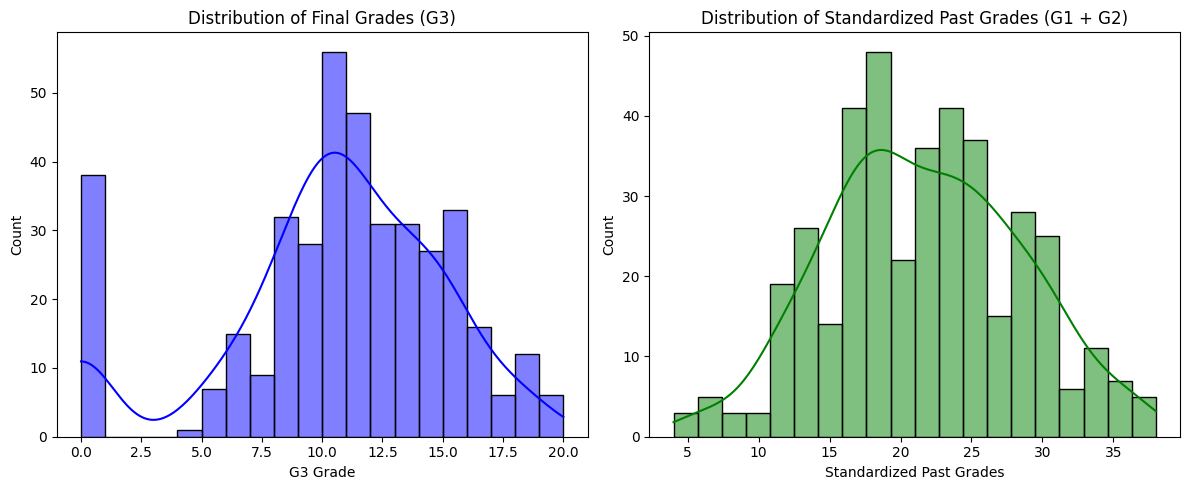

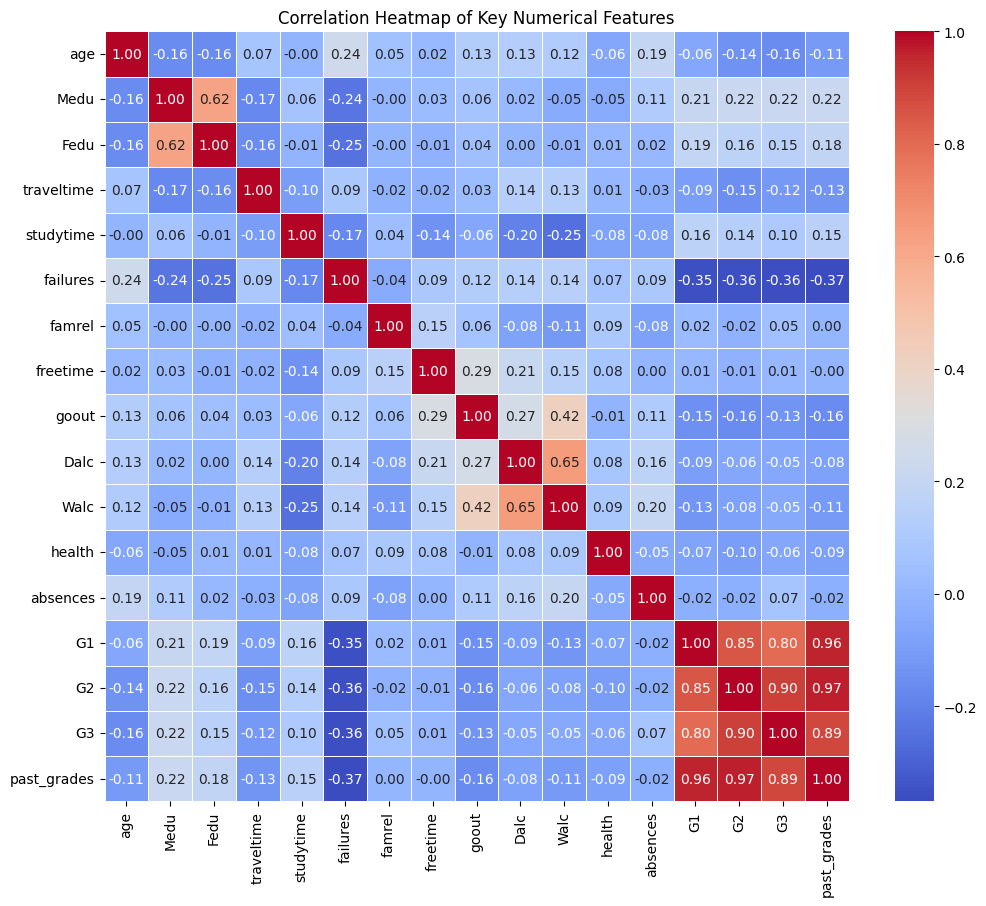

In [ ]:
# 1. Visualize the distribution of target variable and historical grades
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['G3'], kde=True, color='blue', bins=20)
plt.title('Distribution of Final Grades (G3)')
plt.xlabel('G3 Grade')

plt.subplot(1, 2, 2)
# Using past_grades (G1 + G2) instead of total_grades to avoid data leakage
sns.histplot(df_preprocessed['past_grades'], kde=True, color='green', bins=20)
plt.title('Distribution of Standardized Past Grades (G1 + G2)')
plt.xlabel('Standardized Past Grades')

plt.tight_layout()
plt.show()

# 2. Correlation Matrix Heatmap of key numerical features
plt.figure(figsize=(12, 10))
key_features = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures',
                'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health',
                'absences', 'G1', 'G2', 'G3', 'past_grades']

corr_matrix = df_preprocessed[key_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Key Numerical Features')
plt.show()

### Clustering Analysis (K-Means)
We will use the **K-Means** clustering algorithm. Following your project requirements:
1. We will prepare the preprocessed features (excluding the target variable `G3` to capture natural groupings in our features).
2. We will test 5 different clusterings ($k = 2, 3, 4, 5, 6$).
3. We will evaluate these clusterings using both the **Elbow Method (Inertia)** and the **Silhouette Score** to choose the best number of clusters.
4. For the selected optimal $k$, we will plot the clusters using PCA (Principal Component Analysis) to reduce dimensionality to 2D for visualization.
5. We will display and interpret the centroids of our chosen clusters.

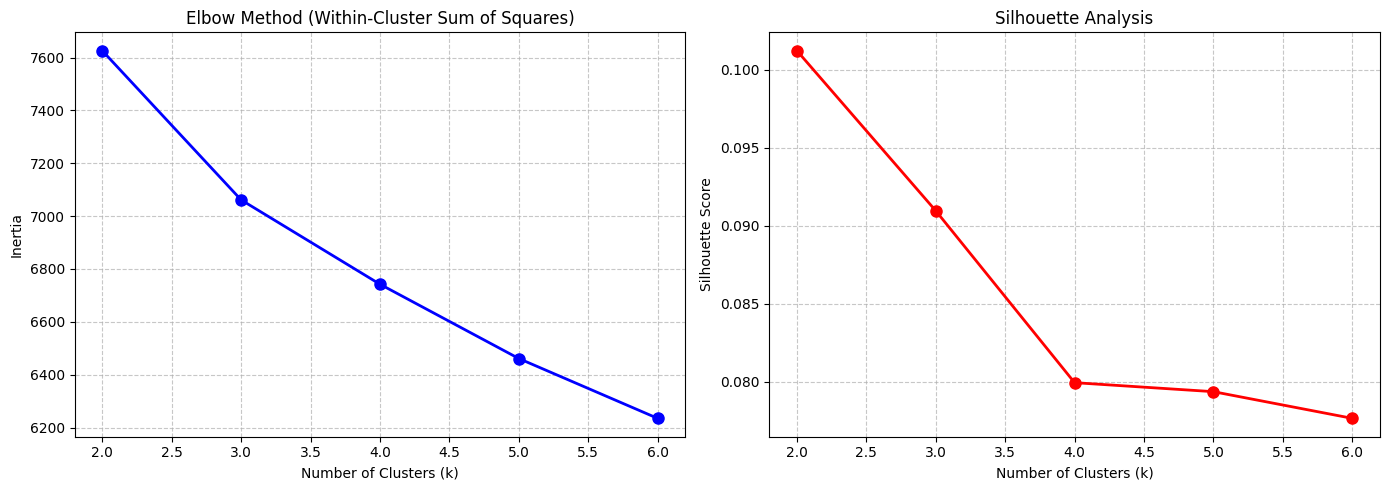

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Ensure df is loaded
try:
    _ = df.shape
except NameError:
    df = pd.read_csv('/content/student-mat.csv', sep=';')

# Ensure X is preprocessed
try:
    _ = X.shape
except NameError:
    df_preprocessed = df.copy()
    q_95 = df_preprocessed['absences'].quantile(0.95)
    df_preprocessed['absences'] = np.where(df_preprocessed['absences'] > q_95, q_95, df_preprocessed['absences'])
    df_preprocessed['past_grades'] = df_preprocessed['G1'] + df_preprocessed['G2']
    df_preprocessed['study_to_free_ratio'] = df_preprocessed['studytime'] / (df_preprocessed['freetime'] + 1e-5)

    binary_cols = ['schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
    for col in binary_cols:
        df_preprocessed[col] = df_preprocessed[col].map({'yes': 1, 'no': 0})
    df_preprocessed['school'] = df_preprocessed['school'].map({'GP': 1, 'MS': 0})
    df_preprocessed['sex'] = df_preprocessed['sex'].map({'F': 1, 'M': 0})
    df_preprocessed['address'] = df_preprocessed['address'].map({'U': 1, 'R': 0})
    df_preprocessed['famsize'] = df_preprocessed['famsize'].map({'GT3': 1, 'LE3': 0})
    df_preprocessed['Pstatus'] = df_preprocessed['Pstatus'].map({'T': 1, 'A': 0})

    multi_class_cols = ['Mjob', 'Fjob', 'reason', 'guardian']
    df_preprocessed = pd.get_dummies(df_preprocessed, columns=multi_class_cols, drop_first=True, dtype=int)
    X = df_preprocessed.drop(columns=['G3'])

# Prepare features for clustering
scaler_clust = StandardScaler()
num_features_clust = ['age', 'absences', 'G1', 'G2', 'past_grades', 'study_to_free_ratio']

X_clust = X.copy()
X_clust[num_features_clust] = scaler_clust.fit_transform(X_clust[num_features_clust])

# Test k values from 2 to 6
k_values = range(2, 7)
inertia_scores = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_clust)
    inertia_scores.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_clust, labels))

# Plot Elbow and Silhouette analysis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Method
ax1.plot(k_values, inertia_scores, 'bo-', linewidth=2, markersize=8)
ax1.set_title('Elbow Method (Within-Cluster Sum of Squares)')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.grid(True, linestyle='--', alpha=0.7)

# Silhouette Scores
ax2.plot(k_values, silhouette_scores, 'ro-', linewidth=2, markersize=8)
ax2.set_title('Silhouette Analysis')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Optimal Cluster Results and Visualization
Let's apply the selected optimal $k$ (we'll analyze $k=3$ as a common choice balancing both inertia dropoff and silhouette score, but the user can adjust based on the plots above). We'll visualize the cluster distribution by reducing our high-dimensional space into 2 components using PCA.

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


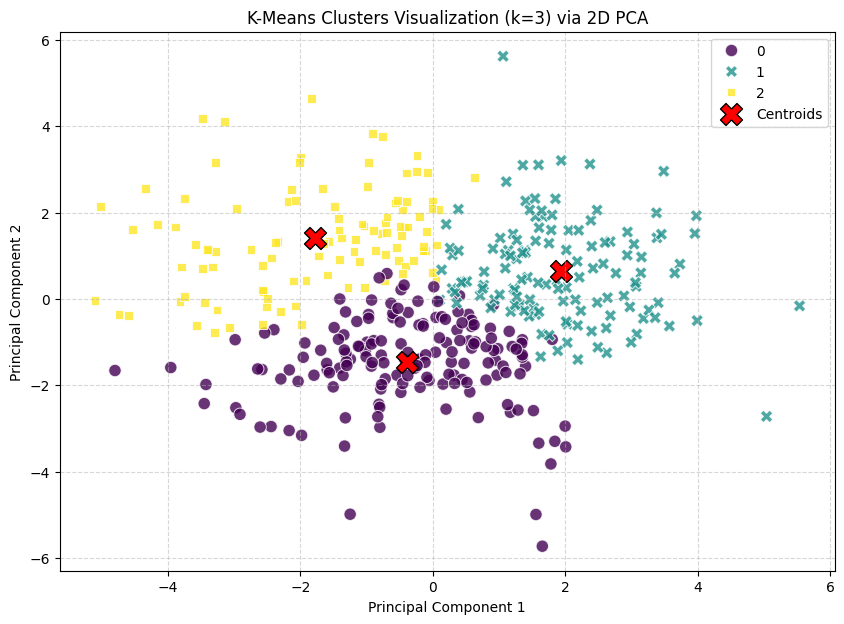

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

best_k = 3
kmeans_best = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans_best.fit_predict(X_clust)

# Safely assign labels back to avoid modification warnings
X_clust_with_labels = X_clust.copy()
X_clust_with_labels['Cluster'] = cluster_labels
df['Cluster'] = cluster_labels

# Reduce dimensionality to 2D using PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_clust_with_labels.drop(columns=['Cluster']))

# Plot the 2D representation of clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=cluster_labels, palette='viridis', style=cluster_labels, s=80, alpha=0.8)

# Project centroids into the same 2D PCA space
centroids_pca = pca.transform(kmeans_best.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], marker='X', s=250, color='red', label='Centroids', edgecolor='black')

plt.title(f'K-Means Clusters Visualization (k={best_k}) via 2D PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Centroid Interpretation
We will inspect the mean attributes of each cluster across key numerical indicators to understand and profile each demographic group.

In [ ]:
# Analyze average features per cluster on the non-scaled original features to get interpretable values
cluster_profile = df.groupby('Cluster')[['G1', 'G2', 'G3', 'studytime', 'freetime', 'failures', 'absences', 'goout']].mean()

print("=== Cluster Profiles (Feature Averages) ===")
display(cluster_profile)

=== Cluster Profiles (Feature Averages) ===


,G1,G2,G3,studytime,freetime,failures,absences,goout
Cluster,,,,,,,,
0,8.955975,8.522013,7.754717,2.169811,2.974843,0.427673,5.811321,2.836478
1,14.269231,14.307692,14.469231,2.169231,3.176923,0.061538,4.238462,2.792308
2,9.716981,9.594340,9.433962,1.669811,3.698113,0.528302,7.358491,3.905660
